<a href="https://colab.research.google.com/github/sonalisanjeevprabu18/Neural-Network-and-Deep-Learning/blob/main/NNDL_EXP8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages
!pip install ultralytics opencv-python-headless Pillow matplotlib -q
!pip install easyocr -q  # Optional: for reading plate text

import subprocess
print('✅ All packages installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 32.5 MB/s eta 0:00:00
✅ All packages installed successfully!


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display, Video, HTML
from google.colab import files
from ultralytics import YOLO
import os
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All libraries imported!


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Option A: Use a pretrained license plate detector from HuggingFace
# This model is specifically trained to detect license/number plates
# ─────────────────────────────────────────────────────────────────────────────

# Download the pretrained license plate detection model
MODEL_URL = "https://github.com/Muhammad-Zeerak-Khan/Automatic-License-Plate-Recognition-using-YOLOv8/raw/main/license_plate_detector.pt"
MODEL_PATH = "license_plate_detector.pt"

if not os.path.exists(MODEL_PATH):
    print("Downloading license plate detection model...")
    !wget -q $MODEL_URL -O $MODEL_PATH
    print("✅ Model downloaded!")
else:
    print("✅ Model already exists, skipping download.")

# Load the model
model = YOLO(MODEL_PATH)
print(f"\n✅ Model loaded: {MODEL_PATH}")
print(f"   Classes: {model.names}")

✅ Model downloaded!

✅ Model loaded: license_plate_detector.pt
   Classes: {0: 'license_plate'}


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: Draw bounding boxes on image and show it
# ─────────────────────────────────────────────────────────────────────────────

def detect_and_display(image_path, conf_threshold=0.3, save_output=True):
    """
    Run YOLO detection on an image and display results.

    Args:
        image_path   : Path to input image
        conf_threshold: Minimum confidence score (0-1)
        save_output  : Whether to save the annotated image
    """
    # Run inference
    results = model.predict(
        source=image_path,
        conf=conf_threshold,
        iou=0.45,
        verbose=False
    )

    result = results[0]
    img_bgr = result.orig_img.copy()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    boxes = result.boxes
    plate_crops = []

    print(f"\n🔍 Detected {len(boxes)} number plate(s)")

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf[0])
        cls  = int(box.cls[0])
        label = f"{model.names[cls]} {conf:.2f}"

        # Draw box
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 230, 80), 3)
        # Draw label background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img_rgb, (x1, y1 - th - 8), (x1 + tw + 4, y1), (0, 230, 80), -1)
        cv2.putText(img_rgb, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

        # Crop plate region
        crop = img_rgb[y1:y2, x1:x2]
        plate_crops.append(crop)
        print(f"   Plate #{i+1}: confidence={conf:.2%}, bbox=[{x1},{y1},{x2},{y2}]")

    # Show full annotated image
    h, w = img_rgb.shape[:2]
    fig_w = min(16, max(8, w / 80))
    fig_h = fig_w * h / w
    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Number Plate Detection — {len(boxes)} plate(s) found', fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()

    # Show cropped plates
    if plate_crops:
        print("\n📋 Cropped Plate Region(s):")
        fig, axes = plt.subplots(1, len(plate_crops), figsize=(4 * len(plate_crops), 2))
        if len(plate_crops) == 1:
            axes = [axes]
        for idx, (ax, crop) in enumerate(zip(axes, plate_crops)):
            ax.imshow(crop)
            ax.axis('off')
            ax.set_title(f'Plate #{idx+1}', fontsize=10)
        plt.tight_layout()
        plt.show()

    # Save annotated image
    if save_output:
        out_path = "output_" + os.path.basename(image_path)
        Image.fromarray(img_rgb).save(out_path)
        print(f"\n💾 Saved annotated image → {out_path}")

    return plate_crops


print("✅ Helper functions ready!")

✅ Helper functions ready!


📁 Upload a car image (JPG, PNG, JPEG):


Saving Car.jpg to Car.jpg

▶ Processing: Car.jpg

🔍 Detected 1 number plate(s)
   Plate #1: confidence=63.91%, bbox=[483,640,934,765]


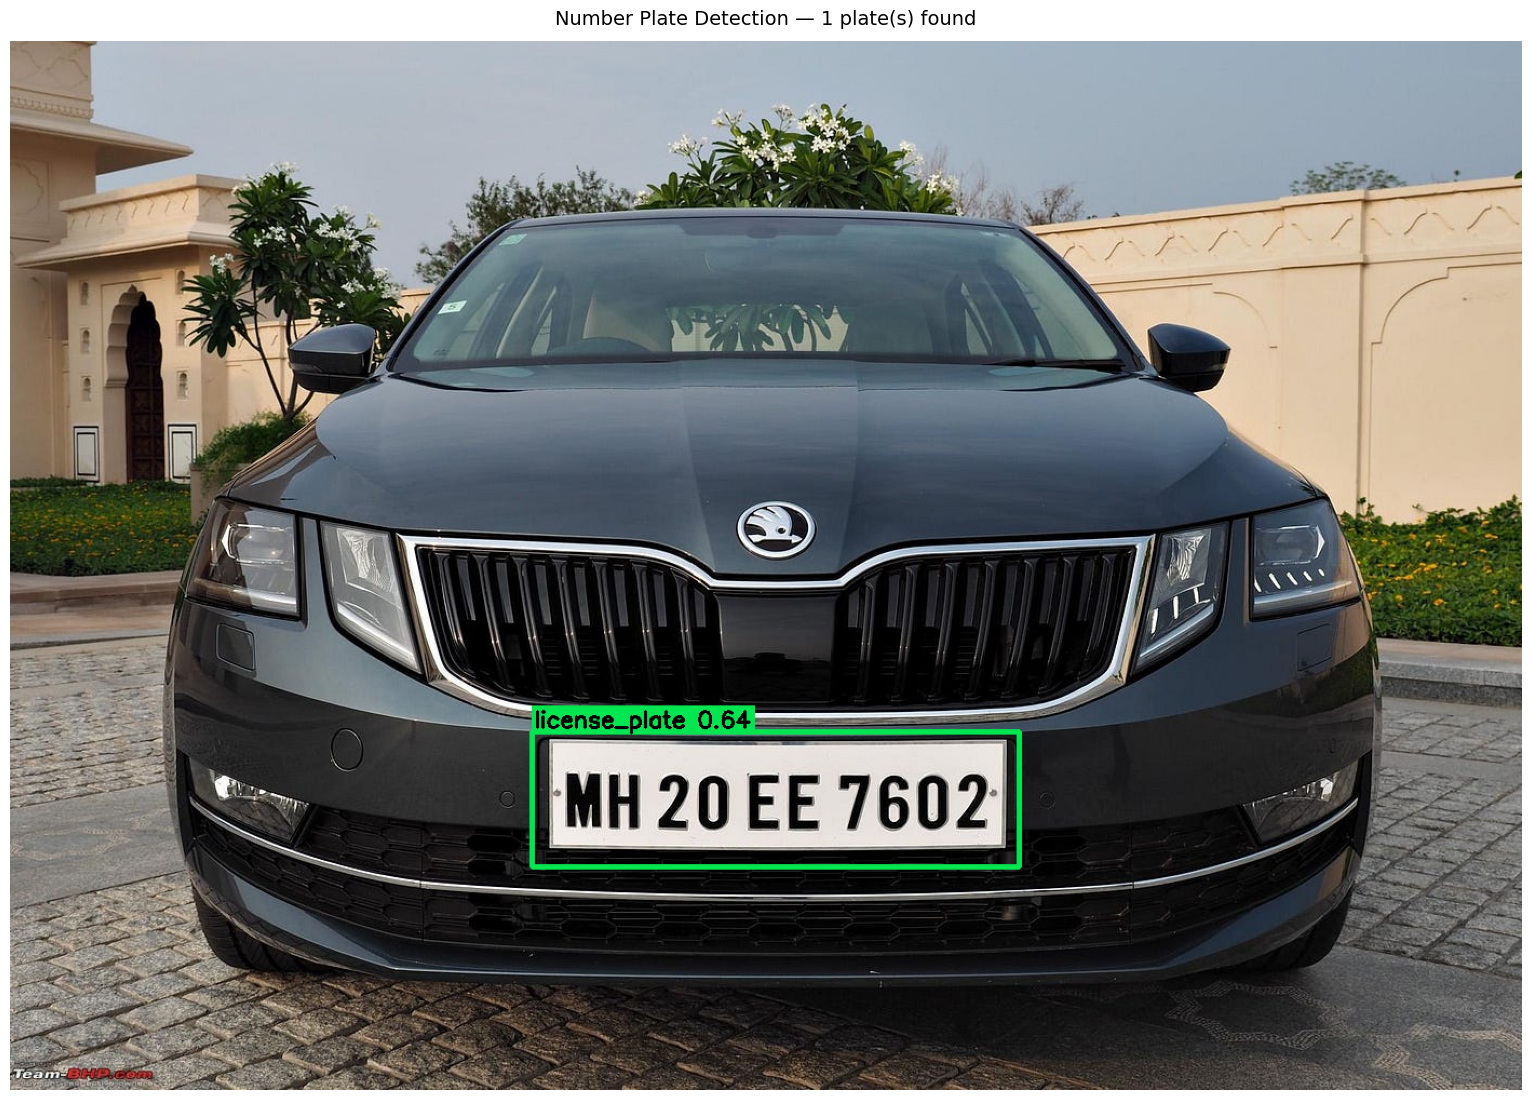


📋 Cropped Plate Region(s):


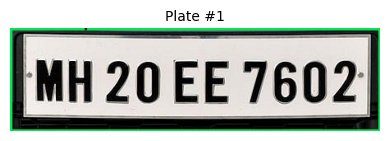


💾 Saved annotated image → output_Car.jpg


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTION 1: Upload your own image
# ─────────────────────────────────────────────────────────────────────────────

print("📁 Upload a car image (JPG, PNG, JPEG):")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n▶ Processing: {filename}")
    plate_crops = detect_and_display(filename, conf_threshold=0.3)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# OCR: Read text from detected plate crops
# ─────────────────────────────────────────────────────────────────────────────

import easyocr

# Initialize OCR reader (downloads model on first run)
print("⏳ Loading OCR model...")
reader = easyocr.Reader(['en'], gpu=True)  # Set gpu=False if no GPU
print("✅ OCR model ready!")


def read_plate_text(plate_crop_rgb):
    """
    Apply OCR to a plate crop and return detected text.

    Args:
        plate_crop_rgb : np.array of the cropped plate (RGB)
    Returns:
        list of detected text strings
    """
    # Preprocess: upscale small plates
    h, w = plate_crop_rgb.shape[:2]
    if w < 200:
        scale = 200 / w
        plate_crop_rgb = cv2.resize(plate_crop_rgb,
                                    (int(w * scale), int(h * scale)),
                                    interpolation=cv2.INTER_CUBIC)

    # Convert to grayscale and apply threshold
    gray = cv2.cvtColor(plate_crop_rgb, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # OCR
    results = reader.readtext(thresh, detail=1)
    texts = [r[1].upper() for r in results if r[2] > 0.2]  # confidence > 20%
    return texts


# ── Run OCR on previously detected plate crops ────────────────────────────────
# (plate_crops is from Step 5A — re-run that cell first if needed)

if 'plate_crops' in dir() and plate_crops:
    print(f"\n🔠 Reading text from {len(plate_crops)} plate(s):\n")
    for i, crop in enumerate(plate_crops):
        texts = read_plate_text(crop)
        plate_text = ' '.join(texts) if texts else '(no text detected)'

        fig, axes = plt.subplots(1, 2, figsize=(8, 2))
        axes[0].imshow(crop)
        axes[0].axis('off')
        axes[0].set_title('Cropped Plate')
        axes[1].text(0.5, 0.5, plate_text, fontsize=18, ha='center', va='center',
                     fontfamily='monospace', fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='#00e650', alpha=0.2))
        axes[1].axis('off')
        axes[1].set_title('OCR Result')
        plt.suptitle(f'Plate #{i+1}: "{plate_text}"', fontsize=12)
        plt.tight_layout()
        plt.show()

        print(f"   Plate #{i+1}: {plate_text}")
else:
    print("⚠️  No plate crops found.")